<a href="https://colab.research.google.com/github/wvb20/cv-face-alignment/blob/main/notebooks/03_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# === Cell 1: Bootstrap — local or Colab ===
import os, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import time

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_PATH = '/content/cv-face-alignment'
    if not os.path.exists(REPO_PATH):
        subprocess.run(
            ['git', 'clone', 'https://github.com/wvb20/cv-face-alignment.git', REPO_PATH],
            check=True,
        )
    else:
        subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'config.py').exists():
            REPO_PATH = str(candidate)
            break
    else:
        raise RuntimeError(
            'Could not find the repo root. Start Jupyter from the repository or set CV_FACE_ALIGNMENT_REPO_ROOT.'
        )

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from src.runtime import configure_notebook_runtime
runtime = configure_notebook_runtime(REPO_PATH)
from src import config, data, evaluate, features, models, visualise, io

print('✓ Setup complete')
runtime_label = 'Colab' if runtime.in_colab else 'Local'
print(f'Runtime:   {runtime_label}')
print(f'Repo:      {runtime.repo_root}')
print(f'Workspace: {runtime.workspace_dir}')

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif device.type == 'mps':
    print('GPU: Apple Metal (MPS)')
elif hasattr(torch.backends, 'mps'):
    print(f"MPS built: {torch.backends.mps.is_built()}, available: {torch.backends.mps.is_available()}")

torch.manual_seed(config.RANDOM_SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete
Runtime:   Local
Repo:      /Users/willvaughn/Developer/cv-face-alignment
Workspace: /Users/willvaughn/Developer/cv-face-alignment
Device: mps
GPU: Apple Metal (MPS)


In [19]:
# === Cell 2: Load data, build train/val datasets ===
images, points = data.load_train()
train_idx, val_idx = data.get_split()

X_train, y_train = images[train_idx], points[train_idx]
X_val,   y_val   = images[val_idx],   points[val_idx]

train_ds = data.FaceLandmarksDataset(X_train, y_train, augment=True)
val_ds   = data.FaceLandmarksDataset(X_val,   y_val,   augment=False)

train_batch_size = 32
eval_batch_size =  64

cpu_count = os.cpu_count() or 1
mps_workers = 0
cpu_workers = min(4, max(1, cpu_count))

if device.type == 'cuda':
    loader_kwargs = dict(num_workers=2, pin_memory=True, persistent_workers=True)
elif device.type == 'mps':
    # MPS is intentionally forced to in-process loading.
    loader_kwargs = dict(
        num_workers=mps_workers,
        pin_memory=False,
        persistent_workers=(mps_workers > 0),
    )
else:
    loader_kwargs = dict(
        num_workers=cpu_workers,
        pin_memory=False,
        persistent_workers=(cpu_workers > 0),
    )

train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True,
                          **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=eval_batch_size, shuffle=False,
                          **loader_kwargs)

print(f'Train: {len(train_ds)} images ({len(train_loader)} batches)')
print(f'Val:   {len(val_ds)} images ({len(val_loader)} batches)')
print(f'Loader settings: {loader_kwargs}')

# Quick sanity check — pull one batch and verify shapes
img_batch, pt_batch = next(iter(train_loader))
print(f'\nOne batch:')
print(f'  Images: {img_batch.shape}, dtype={img_batch.dtype}')
print(f'  Points: {pt_batch.shape}, dtype={pt_batch.dtype}')
print(f'  Image range: [{img_batch.min():.2f}, {img_batch.max():.2f}]  (post-normalisation)')
print(f'  Point range: [{pt_batch.min():.2f}, {pt_batch.max():.2f}]  (should be ~[-1, 1])')

Train: 2390 images (75 batches)
Val:   421 images (7 batches)
Loader settings: {'num_workers': 0, 'pin_memory': False, 'persistent_workers': False}

One batch:
  Images: torch.Size([32, 3, 256, 256]), dtype=torch.float32
  Points: torch.Size([32, 5, 2]), dtype=torch.float32
  Image range: [-1.54, 2.59]  (post-normalisation)
  Point range: [-0.50, 0.52]  (should be ~[-1, 1])


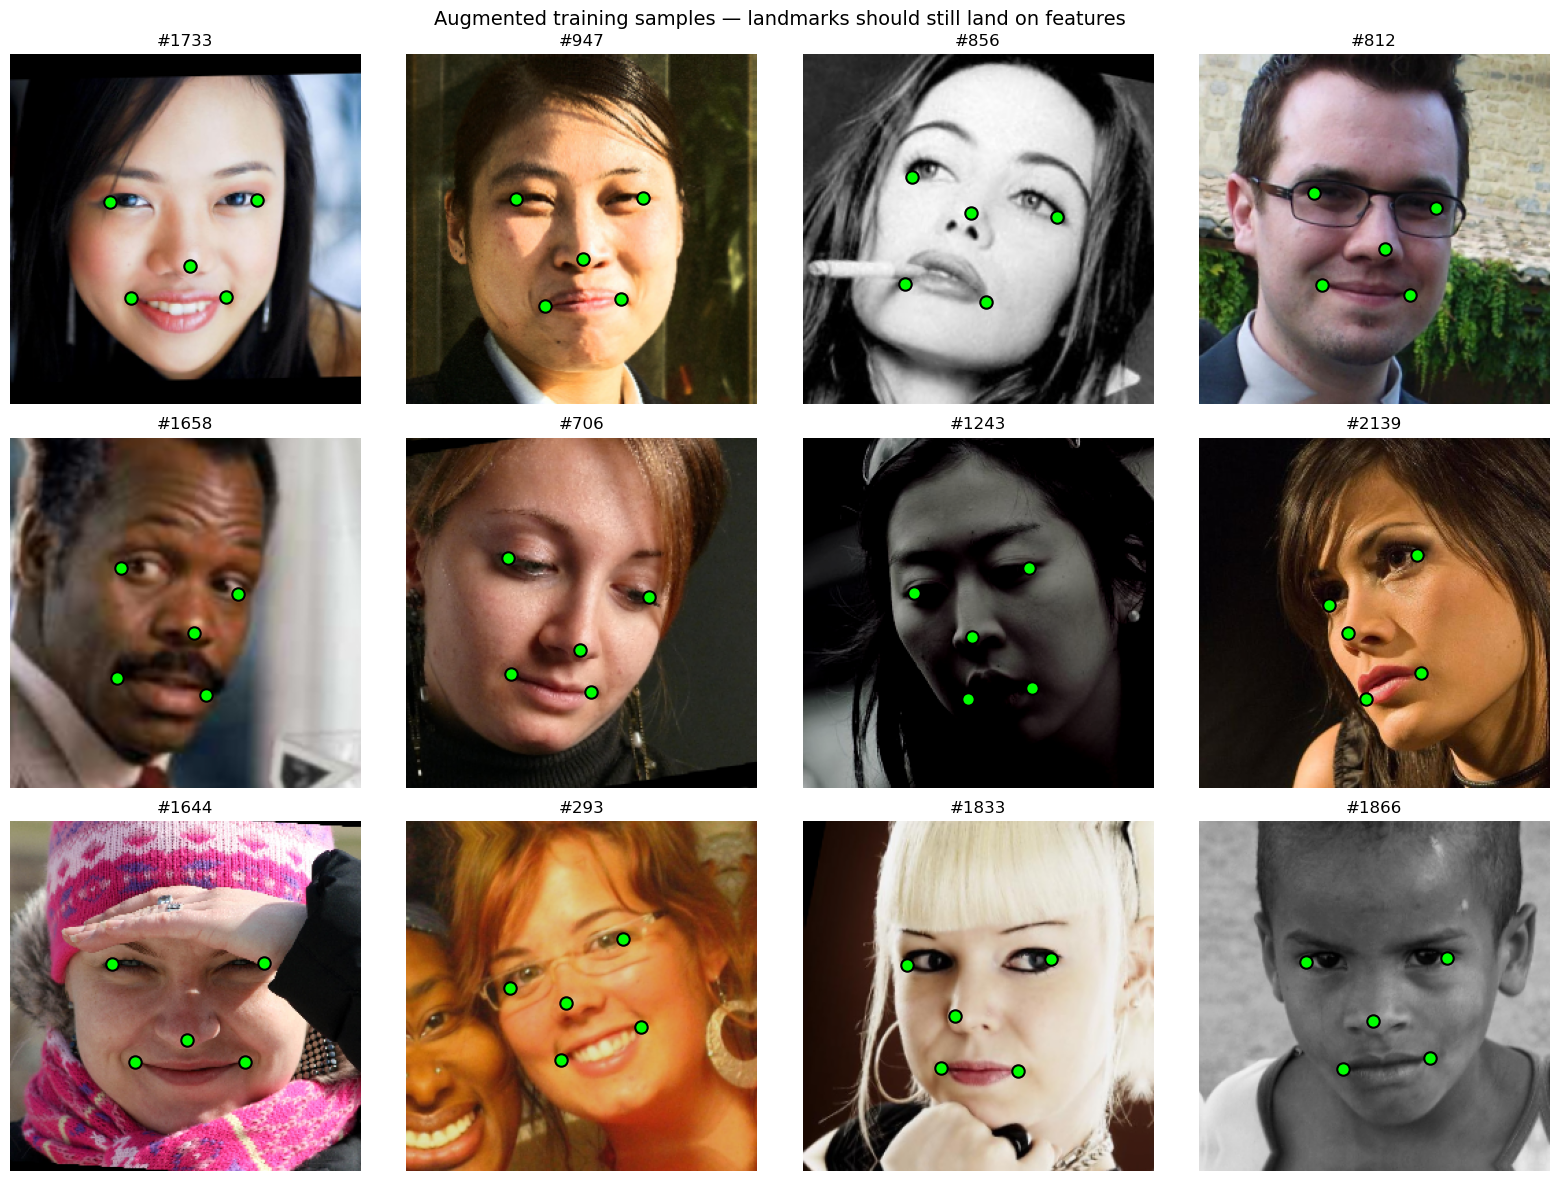

In [20]:
# === Cell 3: Visualise augmented batches to verify landmarks track correctly ===
# Make a fresh dataset so we can call __getitem__ multiple times to see different augs
aug_ds = data.FaceLandmarksDataset(X_train, y_train, augment=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax in axes.flat:
    idx = np.random.randint(len(aug_ds))
    img_t, pt_t = aug_ds[idx]
    # De-normalise image for display
    img_disp = img_t.numpy().transpose(1, 2, 0)
    for c in range(3):
        img_disp[..., c] = img_disp[..., c] * config.NORMALISE_STD[c] + config.NORMALISE_MEAN[c]
    img_disp = np.clip(img_disp, 0, 1)
    # De-normalise points
    pts_disp = models.points_to_pixels(pt_t.numpy(), config.IMAGE_SIZE)

    ax.imshow(img_disp)
    ax.scatter(pts_disp[:, 0], pts_disp[:, 1], s=80, c='lime',
               edgecolors='black', linewidths=1.5)
    ax.set_title(f'#{idx}')
    ax.axis('off')

fig.suptitle('Augmented training samples — landmarks should still land on features',
             fontsize=14)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/09_augmentation_check.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# === Cell 4: Training and validation step functions ===

def _move_to_device(x, device):
    return x.to(device, non_blocking=(device.type == 'cuda'))


def _regression_loss(preds, pts, criterion, device):
    # MPS occasionally returns non-finite reductions for this tiny loss even
    # when inputs are finite, so compute the scalar loss on CPU there.
    #if device.type == 'mps':
    #    return criterion(preds.float().cpu(), pts.float().cpu())
    return criterion(preds, pts)

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    for batch_idx, (imgs, pts) in enumerate(loader, start=1):
        imgs = _move_to_device(imgs, device)
        pts  = _move_to_device(pts, device)

        if not torch.isfinite(imgs).all():
            raise RuntimeError(f'Non-finite images encountered in training batch {batch_idx}.')
        if not torch.isfinite(pts).all():
            raise RuntimeError(f'Non-finite targets encountered in training batch {batch_idx}.')

        optimiser.zero_grad(set_to_none=True)
        preds = model(imgs)
        if not torch.isfinite(preds).all():
            raise RuntimeError(f'Non-finite predictions encountered during training batch {batch_idx}.')
        loss = _regression_loss(preds, pts, criterion, device)
        if not torch.isfinite(loss):
            raise RuntimeError(
                f'Non-finite loss encountered during training batch {batch_idx}. '
                f'pred range=({preds.detach().amin().item():.3f}, {preds.detach().amax().item():.3f}), '
                f'target range=({pts.detach().amin().item():.3f}, {pts.detach().amax().item():.3f})'
            )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    """Returns (mean_loss, all_preds_pixels, all_targets_pixels)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_gts = [], []
    for batch_idx, (imgs, pts) in enumerate(loader, start=1):
        imgs = _move_to_device(imgs, device)
        pts  = _move_to_device(pts, device)

        if not torch.isfinite(imgs).all():
            raise RuntimeError(f'Non-finite images encountered in eval batch {batch_idx}.')
        if not torch.isfinite(pts).all():
            raise RuntimeError(f'Non-finite targets encountered in eval batch {batch_idx}.')

        preds = model(imgs)
        if not torch.isfinite(preds).all():
            raise RuntimeError(f'Non-finite predictions encountered during evaluation batch {batch_idx}.')
        loss = _regression_loss(preds, pts, criterion, device)
        if not torch.isfinite(loss):
            raise RuntimeError(f'Non-finite loss encountered during evaluation batch {batch_idx}.')
        total_loss += loss.item() * imgs.size(0)

        # Convert back to pixel coordinates for NME calc
        preds_px = models.points_to_pixels(preds.detach().cpu().numpy(),
                                            config.IMAGE_SIZE)
        gts_px   = models.points_to_pixels(pts.detach().cpu().numpy(),
                                            config.IMAGE_SIZE)
        all_preds.append(preds_px)
        all_gts.append(gts_px)

    return (total_loss / len(loader.dataset),
            np.concatenate(all_preds),
            np.concatenate(all_gts))

In [ ]:
# === Cell 5: Train CNN ===

model = models.LandmarkCNN(n_landmarks=config.N_LANDMARKS, dropout=0.0).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model: LandmarkCNN, {n_params:,} parameters')

# Smooth L1 (Huber) — robust to outlier landmarks and still cheap to
# evaluate on CPU for the MPS stability workaround in Cell 4.
#criterion = nn.SmoothL1Loss()

# Switch to MSE loss - Smooth L1 resulted in suboptimal outcomes
#criterion = nn.MSELoss()

# Switch to MAE loss - Better Mac performance.
criterion = nn.L1Loss()  # MAE; simpler MPS kernel than SmoothL1, robust

learning_rate = 1e-4 if device.type == 'mps' else 1e-3
optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5
)

N_EPOCHS = 50
best_val_nme = float('inf')
best_epoch = -1
history = {'train_loss': [], 'val_loss': [], 'val_nme': []}

ckpt_path = f'{config.CHECKPOINTS_DIR}/landmark_cnn_spatial_best.pt'

print(f'\nTraining for up to {N_EPOCHS} epochs on {device}...')
print(f'Initial learning rate: {learning_rate:.0e}')
t_start = time.time()
for epoch in range(1, N_EPOCHS + 1):
    start_epoch_time = time.time()
    train_loss = train_one_epoch(model, train_loader, optimiser, criterion, device)
    val_loss, val_preds, val_gts = evaluate_model(model, val_loader, criterion, device)
    val_nme = evaluate.nme(val_preds, val_gts)
    val_nme_mean = float(val_nme.mean())

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_nme'].append(val_nme_mean)

    # Step on NME, not the tiny normalised regression loss.
    scheduler.step(val_nme_mean)
    current_lr = optimiser.param_groups[0]['lr']

    # Save best checkpoint by val NME
    if val_nme_mean < best_val_nme:
        best_val_nme = val_nme_mean
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_nme': val_nme_mean,
        }, ckpt_path)
        marker = ' ★ best'
    else:
        marker = ''

    end_epoch_time = time.time()
    elapsed_epoch_time = end_epoch_time - start_epoch_time

    print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'val NME={val_nme_mean*100:.2f}%  lr={current_lr:.0e} '
          f'Epoc runtime={elapsed_epoch_time/60:.1f} min  {marker}')
    
    

elapsed = time.time() - t_start
print(f'\nTraining done. Total time: {elapsed/60:.1f} min')
print(f'Best val NME: {best_val_nme*100:.2f}% at epoch {best_epoch}')
print(f'Best checkpoint: {ckpt_path}')

Model: LandmarkCNN, 593,482 parameters

Training for up to 50 epochs on mps...
Initial learning rate: 1e-04
Epoch   1/50 | train=0.0681  val=0.0604  val NME=12.40%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   2/50 | train=0.0613  val=0.0564  val NME=11.60%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   3/50 | train=0.0556  val=0.0498  val NME=10.23%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   4/50 | train=0.0503  val=0.0460  val NME=9.52%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   5/50 | train=0.0449  val=0.0428  val NME=8.81%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   6/50 | train=0.0421  val=0.0373  val NME=7.69%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   7/50 | train=0.0399  val=0.0356  val NME=7.34%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   8/50 | train=0.0384  val=0.0332  val NME=6.89%  lr=1e-04 Epoc runtime=0.5 min   ★ best
Epoch   9/50 | train=0.0354  val=0.0341  val NME=7.07%  lr=1e-04 Epoc runtime=0.5 min  
Epoch  10/50 | train=0.0343  val=0.0306  

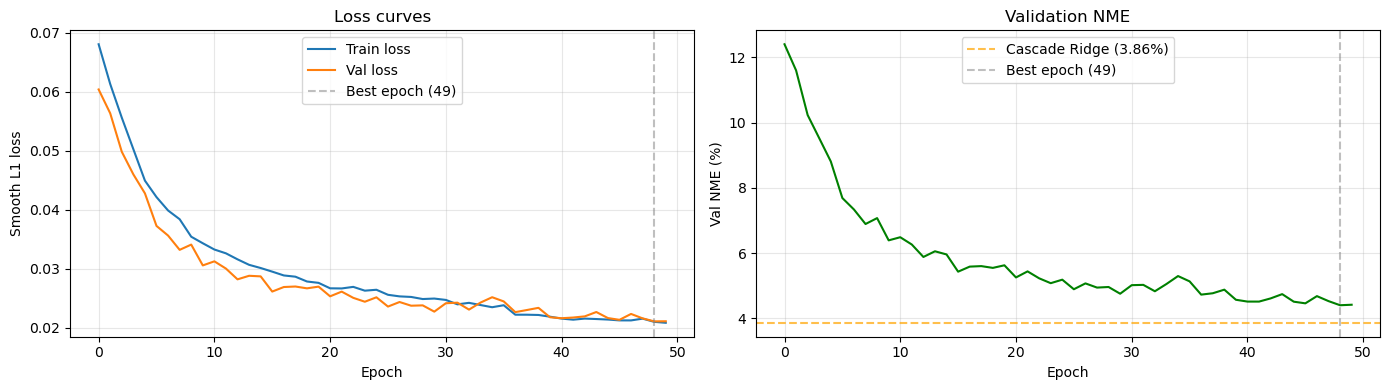

In [ ]:
# === Cell 6: Plot training curves ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].axvline(best_epoch - 1, ls='--', c='grey', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Smooth L1 loss')
axes[0].set_title('Loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([n*100 for n in history['val_nme']], color='green')
axes[1].axhline(3.86, ls='--', c='orange', alpha=0.7,
                label='Cascade Ridge (3.86%)')
axes[1].axvline(best_epoch - 1, ls='--', c='grey', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val NME (%)')
axes[1].set_title('Validation NME')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/10_training_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# === Cell 7: Reload best checkpoint, full evaluation on val ===
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}')

_, val_preds_cnn, val_gts_check = evaluate_model(
    model, val_loader, criterion, device
)
nme_cnn = evaluate.nme(val_preds_cnn, val_gts_check)

print(f'\nCNN validation results:')
print(f'  NME mean   = {nme_cnn.mean()*100:.2f}%')
print(f'  NME median = {np.median(nme_cnn)*100:.2f}%')
print(f'  Failure rate (>10%) = {evaluate.failure_rate(nme_cnn)*100:.1f}%')

Loaded best checkpoint from epoch 49

CNN validation results:
  NME mean   = 4.40%
  NME median = 4.15%
  Failure rate (>10%) = 0.7%


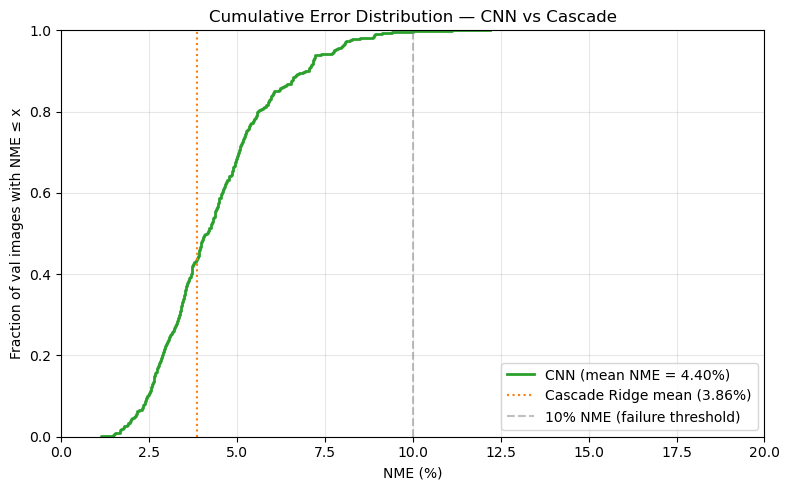


--- Summary ---
  Cascade Ridge: NME = 3.86%, failures = 0.7%
  CNN:           NME = 4.40%, failures = 0.7%


In [ ]:
# === Cell 8: CED comparison vs the cascade baseline ===
# For now, cascaded ridge metrics are hardcoded from earlier run

CASCADE_NME_MEAN   = 3.86 / 100
CASCADE_NME_MEDIAN = 3.44 / 100
CASCADE_FAIL_RATE  = 0.7 / 100


fig, ax = plt.subplots(figsize=(8, 5))

# Re-load the cascade NMEs from disk if you saved them; otherwise just
# annotate them. Simplest approach: rerun cascade in this notebook.
# But we'll plot CNN curve and overlay cascade summary stats:

x_cnn, y_cnn = evaluate.cumulative_error_distribution(nme_cnn)
ax.step(x_cnn * 100, y_cnn,
        label=f'CNN (mean NME = {nme_cnn.mean()*100:.2f}%)',
        color='C2', linewidth=2)

ax.axvline(CASCADE_NME_MEAN * 100, ls=':', c='C1',
           label=f'Cascade Ridge mean ({CASCADE_NME_MEAN*100:.2f}%)')
ax.axvline(10, ls='--', c='grey', alpha=0.5,
           label='10% NME (failure threshold)')

ax.set_xlabel('NME (%)')
ax.set_ylabel('Fraction of val images with NME ≤ x')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
ax.set_title('Cumulative Error Distribution — CNN vs Cascade')
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/11_ced_cnn_vs_cascade.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Summary ---')
print(f'  Cascade Ridge: NME = {CASCADE_NME_MEAN*100:.2f}%, '
      f'failures = {CASCADE_FAIL_RATE*100:.1f}%')
print(f'  CNN:           NME = {nme_cnn.mean()*100:.2f}%, '
      f'failures = {evaluate.failure_rate(nme_cnn)*100:.1f}%')

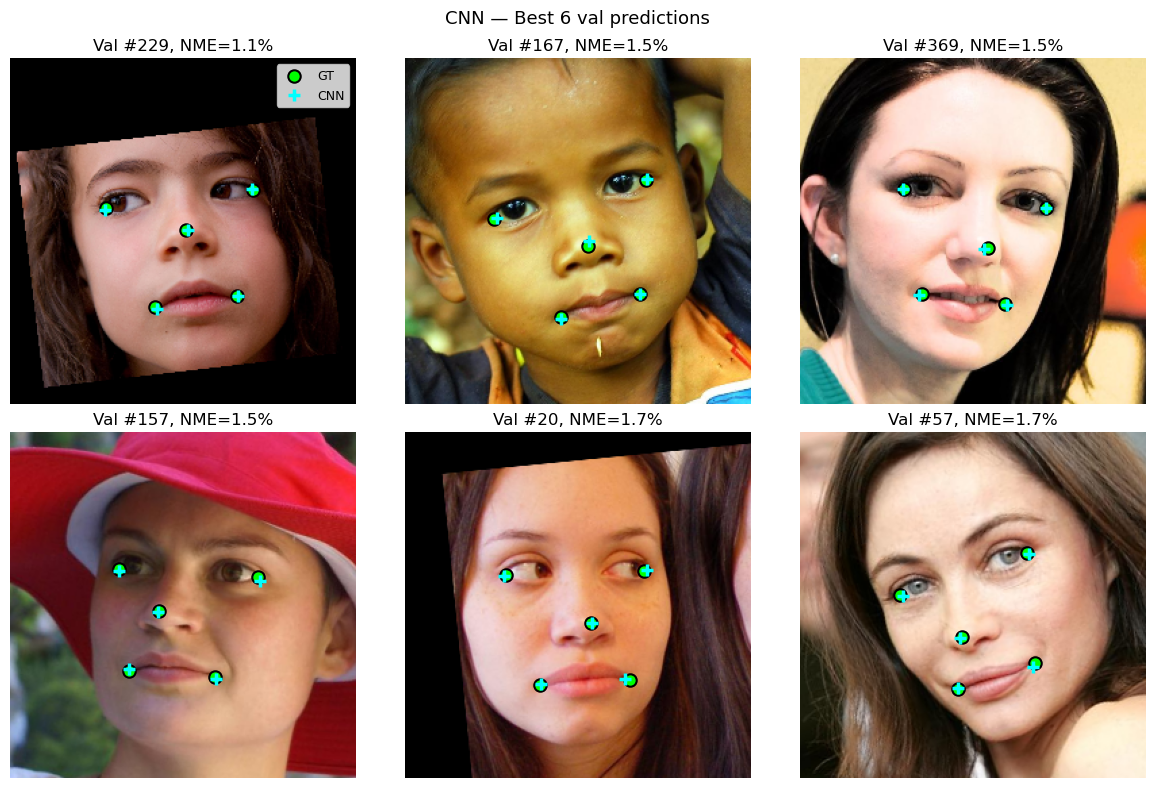

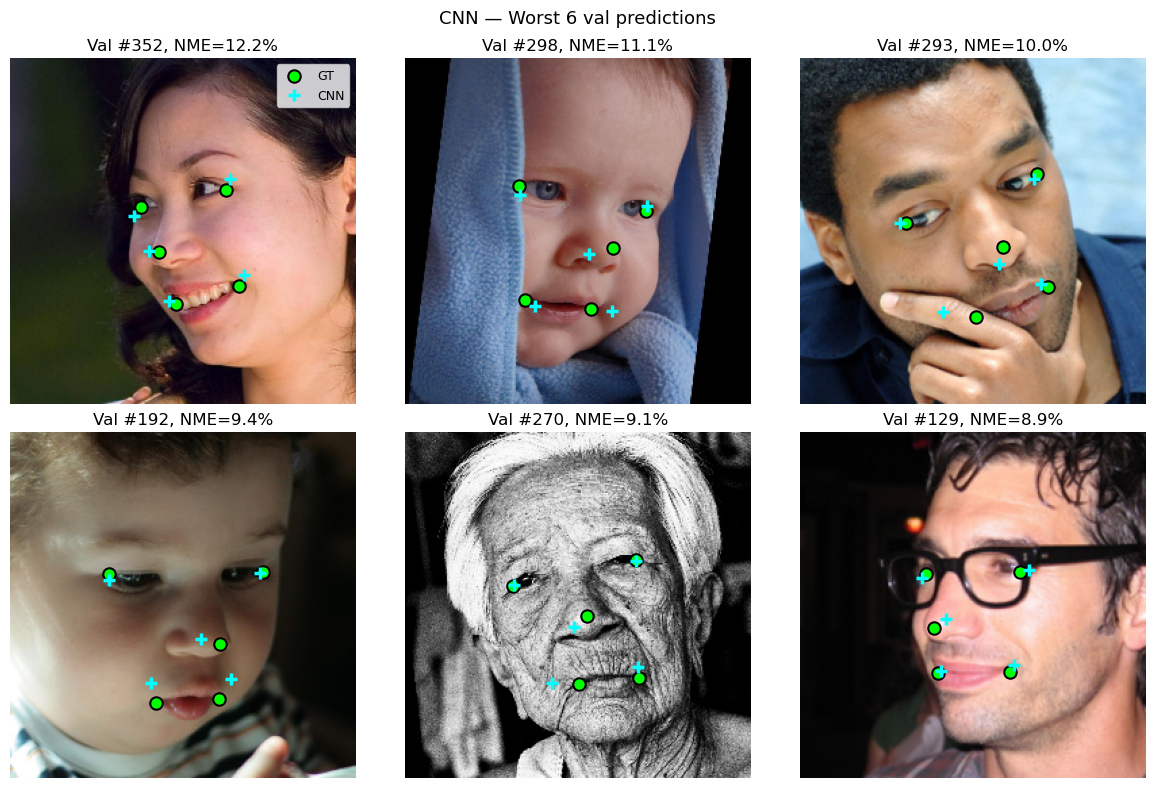

In [ ]:
# === Cell 9: Best-of and worst-of CNN val predictions ===
worst_idx = np.argsort(nme_cnn)[-6:][::-1]
best_idx  = np.argsort(nme_cnn)[:6]

for label, idxs in [('Best 6', best_idx), ('Worst 6', worst_idx)]:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, i in zip(axes.flat, idxs):
        ax.imshow(X_val[i])
        ax.scatter(y_val[i, :, 0], y_val[i, :, 1],
                   s=80, c='lime', edgecolors='black',
                   linewidths=1.5, label='GT', zorder=4)
        ax.scatter(val_preds_cnn[i, :, 0], val_preds_cnn[i, :, 1],
                   s=80, marker='+', c='cyan',
                   linewidths=2.5, label='CNN', zorder=5)
        ax.set_title(f'Val #{i}, NME={nme_cnn[i]*100:.1f}%')
        ax.axis('off')
    axes[0, 0].legend(loc='upper right', fontsize=9)
    fig.suptitle(f'CNN — {label} val predictions', fontsize=13)
    fig.tight_layout()
    plt.savefig(f'{config.FIGURES_DIR}/12_cnn_{label.replace(" ", "_").lower()}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# === Cell 10: Generate CNN test predictions, save as CSV ===
test_images = data.load_test()
print(f'Test set: {test_images.shape}')

# Build a test "dataset" — points are unused but FaceLandmarksDataset needs
# something there. Use zeros; we never look at them.
test_dummy_pts = np.zeros((len(test_images), config.N_LANDMARKS, 2),
                          dtype=np.float32)
test_ds = data.FaceLandmarksDataset(test_images, test_dummy_pts, augment=False)
test_loader = DataLoader(test_ds, batch_size=eval_batch_size, shuffle=False,
                         **loader_kwargs)

model.eval()
all_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).cpu().numpy()
        all_preds.append(models.points_to_pixels(preds, config.IMAGE_SIZE))
y_pred_test_cnn = np.concatenate(all_preds)
print(f'Predictions shape: {y_pred_test_cnn.shape}')

# Save
output_dir = f'{REPO_PATH}/outputs'
os.makedirs(output_dir, exist_ok=True)
io.save_as_csv(y_pred_test_cnn, location=output_dir)

import shutil
src_csv  = f'{output_dir}/results_task2.csv'
dest_csv = f'{output_dir}/results_task2_cnn.csv'
shutil.copy(src_csv, dest_csv)
#workspace_csv = f'{config.DRIVE_PROJECT_DIR}/results_task2_cnn.csv'
#shutil.copy(src_csv, workspace_csv)
print(f'\n✓ Saved CNN predictions to:')
print(f'  {dest_csv}')
#print(f'  {workspace_csv}  (workspace copy)')

Test set: (554, 256, 256, 3)
Predictions shape: (554, 5, 2)

✓ Saved CNN predictions to:
  /Users/willvaughn/Developer/cv-face-alignment/outputs/results_task2_cnn.csv


In [ ]:
# === Cell 11: Verify CNN test CSV is correctly formatted ===
import os
loaded = np.loadtxt(f'{REPO_PATH}/outputs/results_task2_cnn.csv', delimiter=',')
print(f'CSV shape: {loaded.shape}  (expect (554, 10))')
print(f'Range: [{loaded.min():.1f}, {loaded.max():.1f}]')
print(f'File size: {os.path.getsize(f"{REPO_PATH}/outputs/results_task2_cnn.csv"):,} bytes')

# Round-trip: reshape back to (554, 5, 2) and verify it matches the in-memory predictions
loaded_3d = loaded.reshape(554, 5, 2)
matches = np.allclose(loaded_3d, y_pred_test_cnn, atol=1e-6)
print(f'\nRound-trip correctness: {matches}  (CSV ↔ in-memory predictions match)')

# Compare CNN vs cascade test prediction means — should be similar (same data)
cascade_csv = f'{REPO_PATH}/outputs/results_task2_cascade.csv'
if os.path.exists(cascade_csv):
    cascade = np.loadtxt(cascade_csv, delimiter=',').reshape(554, 5, 2)
    print(f'\nCascade test mean: {cascade.mean(axis=0).round(1).tolist()}')
    print(f'CNN test mean:     {y_pred_test_cnn.mean(axis=0).round(1).tolist()}')
    diff = np.linalg.norm(cascade.mean(axis=0) - y_pred_test_cnn.mean(axis=0), axis=1).mean()
    print(f'Mean per-landmark difference: {diff:.2f} pixels  (small = methods agree)')
else:
    print(f'\n(No cascade CSV found at {cascade_csv} — skip comparison)')

CSV shape: (554, 10)  (expect (554, 10))
Range: [61.7, 196.4]
File size: 138,500 bytes

Round-trip correctness: True  (CSV ↔ in-memory predictions match)

Cascade test mean: [[80.5, 104.7], [175.5, 102.7], [129.3, 142.5], [99.3, 175.9], [160.9, 174.3]]
CNN test mean:     [[79.5, 105.5999984741211], [174.89999389648438, 102.19999694824219], [128.3000030517578, 141.3000030517578], [98.30000305175781, 175.8000030517578], [161.39999389648438, 173.3000030517578]]
Mean per-landmark difference: 1.11 pixels  (small = methods agree)


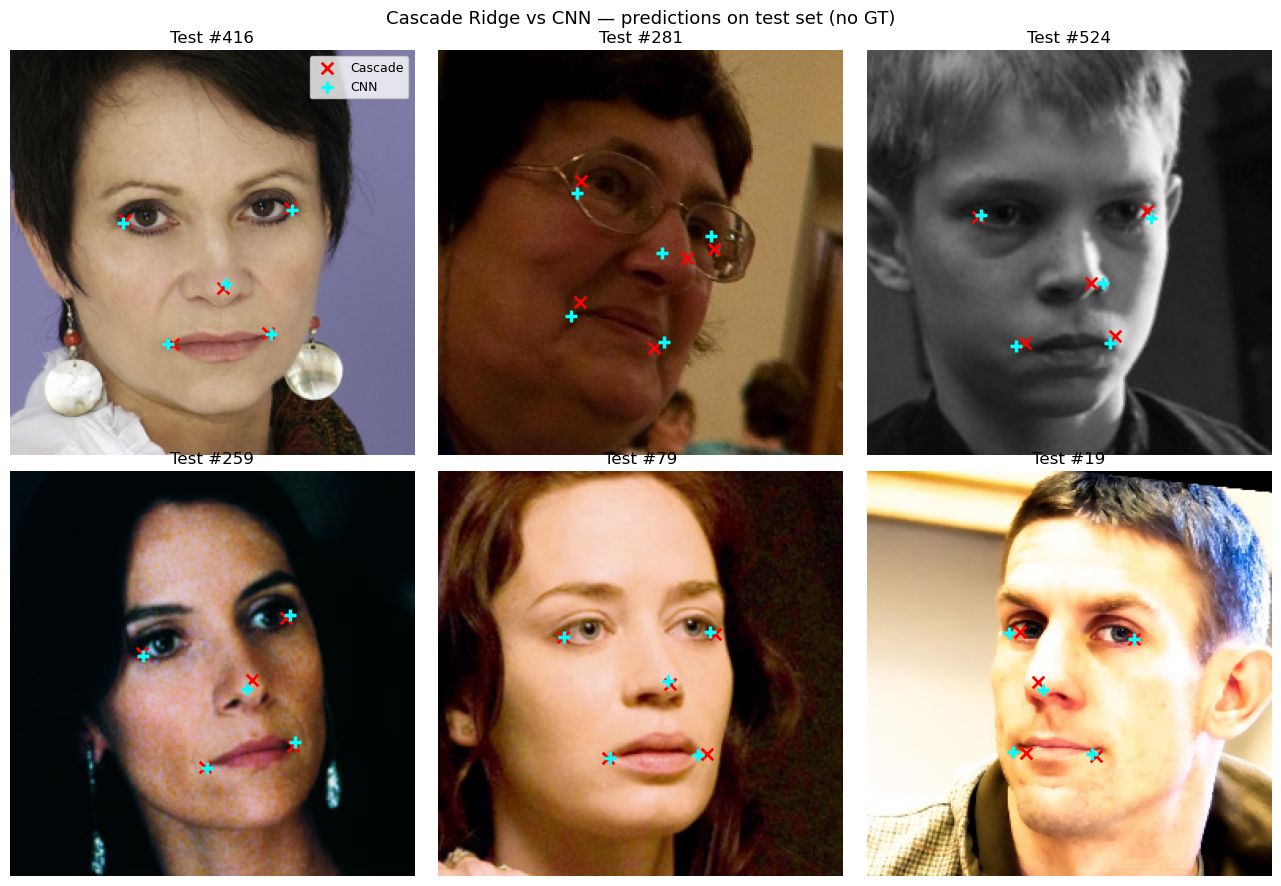

In [ ]:
# === Cell 12: Cascade vs CNN test predictions on 6 random images ===
cascade_csv = f'{REPO_PATH}/outputs/results_task2_cascade.csv'
y_pred_test_cascade = np.loadtxt(cascade_csv, delimiter=',').reshape(554, 5, 2)

rng = np.random.default_rng(seed=1)
test_sample = rng.choice(len(test_images), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, test_sample):
    ax.imshow(test_images[i])
    ax.scatter(y_pred_test_cascade[i, :, 0], y_pred_test_cascade[i, :, 1],
               s=70, marker='x', c='red', linewidths=2,
               label='Cascade', zorder=4)
    ax.scatter(y_pred_test_cnn[i, :, 0], y_pred_test_cnn[i, :, 1],
               s=80, marker='+', c='cyan', linewidths=2.5,
               label='CNN', zorder=5)
    ax.set_title(f'Test #{i}')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=9)
fig.suptitle('Cascade Ridge vs CNN — predictions on test set (no GT)', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/14_cascade_vs_cnn_test.png',
            dpi=120, bbox_inches='tight')
plt.show()

Recomputing classical baselines on the current train/val split...
Done in 28.3s

Validation comparison on the shared split
Model                            Mean NME % Median NME %   Fail %
------------------------------------------------------------------
Cascaded Ridge (4 stages)              3.86         3.45      0.7
CNN                                    4.40         4.15      0.7
Single-stage Ridge (SIFT)              4.99         4.54      3.6
Mean shape                            12.60        11.29     60.3

Best mean NME: Cascaded Ridge (4 stages)


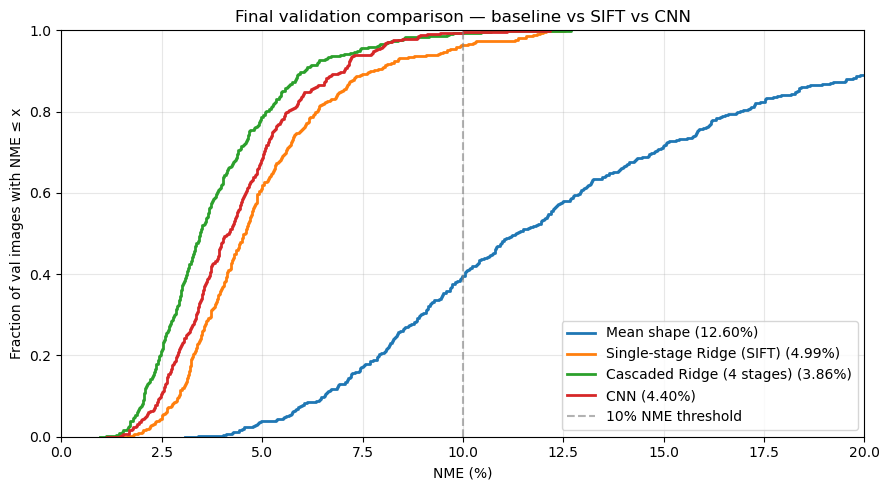

In [ ]:
# === Cell 13: Final validation comparison — all models side by side ===
from sklearn.linear_model import Ridge

print('Recomputing classical baselines on the current train/val split...')
t_compare = time.time()

PATCH_SIZE = 16
RIDGE_ALPHA = 10.0
CASCADE_STAGES = 4

mean_shape = features.mean_shape(y_train)
y_pred_mean = np.tile(mean_shape, (len(y_val), 1, 1))
nme_mean = evaluate.nme(y_pred_mean, y_val)

X_train_feats = np.stack([
    features.compute_sift_at_points(img, mean_shape, patch_size=PATCH_SIZE)
    for img in X_train
]).astype(np.float32)
X_val_feats = np.stack([
    features.compute_sift_at_points(img, mean_shape, patch_size=PATCH_SIZE)
    for img in X_val
]).astype(np.float32)

y_train_offset = (y_train - mean_shape).reshape(len(y_train), -1)
ridge = Ridge(alpha=RIDGE_ALPHA)
ridge.fit(X_train_feats, y_train_offset)
pred_offset = ridge.predict(X_val_feats)
y_pred_ridge = pred_offset.reshape(-1, config.N_LANDMARKS, 2) + mean_shape
nme_ridge = evaluate.nme(y_pred_ridge, y_val)

cascade_compare = models.CascadedRidgeRegressor(
    n_stages=CASCADE_STAGES,
    alpha=RIDGE_ALPHA,
    patch_size=PATCH_SIZE,
)
cascade_compare.fit(X_train, y_train, verbose=False)
y_pred_cascade_compare = cascade_compare.predict(X_val)
nme_cascade_compare = evaluate.nme(y_pred_cascade_compare, y_val)

comparison_metrics = {
    'Mean shape': nme_mean,
    'Single-stage Ridge (SIFT)': nme_ridge,
    f'Cascaded Ridge ({CASCADE_STAGES} stages)': nme_cascade_compare,
    'CNN': nme_cnn,
}

comparison_rows = []
for label, errors in comparison_metrics.items():
    comparison_rows.append(
        (
            label,
            float(errors.mean() * 100),
            float(np.median(errors) * 100),
            float(evaluate.failure_rate(errors) * 100),
        )
    )
comparison_rows.sort(key=lambda row: row[1])

elapsed_compare = time.time() - t_compare
print(f'Done in {elapsed_compare:.1f}s\n')
print('Validation comparison on the shared split')
print(f'{"Model":<32} {"Mean NME %":>10} {"Median NME %":>12} {"Fail %":>8}')
print('-' * 66)
for label, mean_pct, median_pct, fail_pct in comparison_rows:
    print(f'{label:<32} {mean_pct:>10.2f} {median_pct:>12.2f} {fail_pct:>8.1f}')

best_model = comparison_rows[0][0]
print(f'\nBest mean NME: {best_model}')

fig, ax = plt.subplots(figsize=(9, 5))
colors = {
    'Mean shape': 'C0',
    'Single-stage Ridge (SIFT)': 'C1',
    f'Cascaded Ridge ({CASCADE_STAGES} stages)': 'C2',
    'CNN': 'C3',
}
for label, errors in comparison_metrics.items():
    x, y = evaluate.cumulative_error_distribution(errors)
    ax.step(
        x * 100,
        y,
        where='post',
        linewidth=2,
        color=colors[label],
        label=f'{label} ({errors.mean() * 100:.2f}%)',
    )
ax.axvline(10, ls='--', c='grey', alpha=0.6, label='10% NME threshold')
ax.set_xlabel('NME (%)')
ax.set_ylabel('Fraction of val images with NME ≤ x')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
ax.set_title('Final validation comparison — baseline vs SIFT vs CNN')
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/15_final_validation_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
